# lite version

In [10]:
import torch
import torch.nn.functional as F
import dask.array as da
import json
import shapely
import numpy as np
import geopandas as gpd
from omnialigner.plotting.h5ad_viz import gdf_shape_to_image
from omnialigner.utils.image_pad import center_pad_with_flank
from omnialigner.utils.field_transform import tfrs_to_grid_M, grid_2d_to_disp_field

from omnialigner.utils.image_transform import apply_tfrs_to_dask
from omnialigner.utils.field_transform import calculate_M_from_theta, tfrs_inv, grid_M_to_tfrs
from omnialigner.utils.point_transform import transform_keypoints

import omnialigner as om

%reload_ext autoreload
%autoreload 2

plt = om.pl.plt

In [11]:
from tqdm import tqdm
from omnialigner.utils.point_transform import warp_landmark_grid_faiss



def raw_kpt_to_pad(np_kpts, file_qptiff, crop_size=None, ratio=1.0, pad_size=None, zoom_level=4, use_page=False):
    """
    Transform cell keypoints from original coordinates to padded image coordinates.
    
    Transformation steps:
    1. Load cells and get centroids in original image space
    2. Apply crop offset (if cropped)
    3. Scale by pyramid level (2^zoom_level)
    4. Scale by resize ratio
    5. Apply padding offset
    """
    
    # Step 1: Get centroids in original coordinates
    
    # Step 2: Scale by pyramid level
    np_kpts = np_kpts / (2 ** zoom_level)
    kwargs = {}
    if use_page:
        kwargs["i_page"] = zoom_level
    else:
        kwargs["i_level"] = zoom_level

    # Step 3: Apply crop offset
    if crop_size is not None:
        y1, x1, y2, x2 = crop_size
        da_img0 = om.tl.read_ome_tiff(file_qptiff, i_page=0, i_level=0)
        h, w = da_img0.shape[0], da_img0.shape[1]
    
        crop_offset = np.array([x1 * w, y1 * h])
        np_kpts = np_kpts - crop_offset
    
    # Step 4: Scale by resize ratio
    np_kpts = np_kpts / ratio
    
    # Step 5: Apply padding offset (left, top)
    if pad_size is not None:
        np_pad = np.array([pad_size[0], pad_size[2]])
        np_kpts = np_kpts + np_pad

    return np_kpts

def pad_kpt_to_align(np_kpts, gridM, max_size=1280):
    coords_normalized = torch.from_numpy(np_kpts).float() / max_size
    coords_warped = warp_landmark_grid_faiss(
        coords_normalized,  # Add batch dimension
        grid=gridM[0:1]
    )[:, 0, :]  # Shape: [N_total, 2]
    coords_warped_denorm = coords_warped.numpy() * max_size
    return coords_warped_denorm


def apply_cell_movement(gdf1: gpd.GeoDataFrame, gridM: torch.FloatTensor, max_size=1280):
    gdf1_transformed = gdf1.copy()

    # Step 1: Extract all coordinates and track their indices
    all_coords = []
    coord_indices = []  # Track which geometry each coordinate belongs to
    coord_counts = []   # Track how many coordinates each geometry has

    for idx in tqdm(range(len(gdf1_transformed)), "Extracting coordinates"):
        geom = gdf1_transformed.loc[idx, 'geometry']
        
        if geom.geom_type == 'Polygon':
            coords = np.array(geom.exterior.coords[:-1])
        elif geom.geom_type == 'Point':
            coords = np.array([[geom.x, geom.y]])
        else:
            coord_counts.append(0)
            continue
        
        all_coords.append(coords)
        coord_indices.extend([idx] * len(coords))
        coord_counts.append(len(coords))

    # Step 2: Batch transform all coordinates at once
    if len(all_coords) > 0:
        all_coords_concat = np.vstack(all_coords)  # Shape: [N_total, 2]
        
        coords_warped_denorm = pad_kpt_to_align(all_coords_concat, gridM)
        
        # Step 3: Distribute transformed coordinates back to geometries
        start_idx = 0
        geom_idx = 0
        for idx in tqdm(range(len(gdf1_transformed)), "Transforming back geometries"):
            if coord_counts[idx] == 0:
                continue
                
            geom = gdf1_transformed.loc[idx, 'geometry']
            end_idx = start_idx + coord_counts[idx]
            coords_transformed = coords_warped_denorm[start_idx:end_idx]
            
            # Create new geometry
            if geom.geom_type == 'Polygon':
                gdf1_transformed.loc[idx, 'geometry'] = shapely.Polygon(coords_transformed)
            elif geom.geom_type == 'Point':
                gdf1_transformed.loc[idx, 'geometry'] = shapely.Point(coords_transformed[0])
            
            start_idx = end_idx


    return gdf1_transformed



In [12]:


class AlignmentParams(object):
    def __init__(self, sample, 
                read_tiff_kwargs: dict = None,
                file_qptiff_template: str = '/cluster/home/bqhu_jh/projects/scGaussian3dGen/data/panlab/pdac2/%s.qptiff',
                file_geojson_template: str = '/cluster/home/bqhu_jh/projects/scGaussian3dGen/analysis/panlab/v6/trident_processed/pdac2/%s/contours_geojson/%s.geojson',
                file_cell_gpd_template: str = '/cluster/home/bqhu_jh/projects/scGaussian3dGen/analysis/panlab/v6/lazy_slide/pdac2/%s_cellseg_plip.zarr/shapes/cells/shapes.parquet',
                max_height:int = 1280,
                max_width:int = 1280,
                max_size:int = 1280,
                pt_bg = torch.ones((1, 3, 1, 1)).float(),
                crop_size: np.ndarray = None,
                pad_size: np.ndarray = None,
                ratio: float = 1.0,
                tensor_tfrs_pose: torch.FloatTensor = None,
                grid_M: list = None):
        """
        Initialize alignment parameters with file path templates.
        
        Args:
            sample: Sample name (e.g., "HE_10")
            read_tiff_kwargs: Dictionary of kwargs for reading TIFF files
            file_qptiff_template: Template for QPTIFF file path with %s placeholder
            file_geojson_template: Template for GeoJSON file path with %s placeholders (needs 2 for sample name)
            file_cell_gpd_template: Template for cell segmentation parquet file path with %s placeholder
            crop_size: Crop region [y1, x1, y2, x2] in normalized coordinates
            pad_size: Padding size [left, right, top, bottom]
            ratio: Resize ratio
            zoom_level: Pyramid zoom level
            tensor_tfrs_pose: Transformation pose tensor
            grid_M: List of transformation grids
        """
        self.sample = sample
        self.read_tiff_kwargs = read_tiff_kwargs if read_tiff_kwargs is not None else {}
        self.file_qptiff_template = file_qptiff_template
        self.file_geojson_template = file_geojson_template
        self.file_cell_gpd_template = file_cell_gpd_template
        self.get_file_paths()
        self.max_height = max_height
        self.max_width = max_width
        self.max_size = max_size
        self.pt_bg = pt_bg

        self.crop_size = crop_size
        self.pad_size = pad_size
        self.ratio = ratio
        self.zoom_level = max(self.read_tiff_kwargs.get("i_level", 0), self.read_tiff_kwargs.get("i_page", 0))
        self.tensor_tfrs_pose = tensor_tfrs_pose
        self.gdf_cell = None
        self.grid_M = grid_M if grid_M is not None else []
        
    def __getitem__(self, key):
        """Support dictionary-style access: attr["ratio"]"""
        if hasattr(self, key):
            return getattr(self, key)
        raise KeyError(f"'{key}' not found in AlignmentParams")
    
    def __setitem__(self, key, value):
        """Support dictionary-style assignment: attr["ratio"] = 1.5"""
        setattr(self, key, value)
    
    def __contains__(self, key):
        """Support 'in' operator: "ratio" in attr"""
        return hasattr(self, key)
    
    def get(self, key, default=None):
        """Dictionary-style get with default value"""
        return getattr(self, key, default)
    
    def update(self, other_dict):
        """Update multiple attributes from dictionary"""
        for key, value in other_dict.items():
            setattr(self, key, value)
        return self
    
    def keys(self):
        """Return all attribute keys"""
        return [k for k in self.__dict__.keys() if not k.startswith('_')]
    
    def values(self):
        """Return all attribute values"""
        return [getattr(self, k) for k in self.keys()]
    
    def items(self):
        """Return key-value pairs"""
        return [(k, getattr(self, k)) for k in self.keys()]
    
    def to_dict(self):
        """Convert to dictionary"""
        dict_ = self.get_file_paths()
        for k in self.keys():
            dict_[k] = getattr(self, k)
        return dict_

    def get_file_paths(self):
        """Generate file paths for the current sample"""
        self.file_qptiff = self.file_qptiff_template % self.sample
        self.file_geojson = self.file_geojson_template % (self.sample, self.sample)
        self.file_cell_gpd = self.file_cell_gpd_template % self.sample
        return {
            'file_qptiff': self.file_qptiff_template % self.sample,
            'file_geojson': self.file_geojson_template % (self.sample, self.sample),
            'file_cell_gpd': self.file_cell_gpd_template % self.sample
        }
    
    def copy(self):
        """Create a deep copy of this object"""
        import copy
        return copy.deepcopy(self)
    
    def __repr__(self):
        """String representation"""
        attrs = ', '.join(f"{k}={repr(v)}" for k, v in self.items())
        return f"AlignmentParams({attrs})"
    
    def __str__(self):
        """Human-readable string representation"""
        lines = [f"AlignmentParams for sample '{self.sample}':"]
        for k, v in self.items():
            if isinstance(v, (torch.Tensor, np.ndarray)):
                lines.append(f"  {k}: {type(v).__name__} {getattr(v, 'shape', 'N/A')}")
            elif isinstance(v, str) and len(v) > 50:
                lines.append(f"  {k}: {v[:47]}...")
            else:
                lines.append(f"  {k}: {v}")
        return '\n'.join(lines)


    def viz_cells(self, subsample=-1) -> gpd.GeoDataFrame:
        if self.gdf_cell is None:
            return 

        gdf_cell = self.gdf_cell.copy()
        if subsample > 0:
            gdf_cell = gdf_cell.sample(n=min(subsample, len(gdf_cell)), random_state=42).reset_index()

        if self.grid_M is None or len(self.grid_M) == 0:
            return gdf_cell
        
        
        for grid_M in self.grid_M:
            gdf_cell = apply_cell_movement(gdf_cell, grid_M)
        
        return gdf_cell
    
    def viz_image(self, zoom_level=0, use_page=False) -> da.Array:
        from omnialigner.align import apply_image_HD
        kwargs = self.read_tiff_kwargs.copy()
        zoom_tag = "i_page" if use_page else "i_level"
        kwargs[zoom_tag] = zoom_level
        
        image_HD = om.tl.read_ome_tiff(self.file_qptiff, **kwargs)

        affine_matrix = np.zeros([3, 3])
        affine_matrix[0, 0] = self.ratio
        affine_matrix[1, 1] = self.ratio

        l_disps = None if len(self.grid_M) < 2 else [grid_2d_to_disp_field(grid_M) for grid_M in self.grid_M[1:]]

        scale_up = 2**self.read_tiff_kwargs[zoom_tag] / 2**kwargs[zoom_tag]
        pad_size = [self.pad_size[0]*scale_up, self.pad_size[1]*scale_up, self.pad_size[2]*scale_up, self.pad_size[3]*scale_up] if self.pad_size is not None else None
        return apply_image_HD(
            image_HD,
            crop_size=self.crop_size,
            pad_size=pad_size,
            affine_matrix=affine_matrix,
            tensor_tfrs_1=self.tensor_tfrs_pose,
            l_disps=l_disps,
            **{"constant_values": int(255 * self.pt_bg.mean().item())}
        )
    
    def viz_keypoint(self, kpt=None, is_raw=True, zoom_level=0, use_page=False):
        if kpt is None:
            return

        if is_raw:
            kpt = raw_kpt_to_pad(kpt, self.file_qptiff, crop_size=self.crop_size, ratio=self.ratio, pad_size=self.pad_size, zoom_level=zoom_level, use_page=use_page)
        
        for grid_M in self.grid_M:
            kpt = pad_kpt_to_align(kpt, grid_M, self.max_size)

        return kpt


In [13]:


# 使用示例
sample0 = "HE_10"
sample1 = "HE_131"
attr0 = AlignmentParams("HE_10")

# 字典式访问
print(attr0["ratio"])  # 1.0
attr0["ratio"] = 1.5
print(attr0.ratio)  # 1.5

# 批量更新
attr0.update({
    "pad_size": [0, 0, 0, 0],
    "ratio": 0.8,
    "zoom_level": 4,
    "read_tiff_kwargs": {
        'i_level': 4,
        'i_page': 0,
        'l_channels': [0, 1, 2],
    }
})

# 获取文件路径
paths = attr0.get_file_paths()
print(paths['file_qptiff'])

# 检查属性
if "crop_size" in attr0:
    print("Has crop_size")

# 转换为字典
params_dict = attr0.to_dict()

# 复制对象
attr1 = attr0.copy()
attr1.sample = sample1

# 打印
print(attr0)
print(attr1)

1.0
1.5
/cluster/home/bqhu_jh/projects/scGaussian3dGen/data/panlab/pdac2/HE_10.qptiff
Has crop_size
AlignmentParams for sample 'HE_10':
  sample: HE_10
  read_tiff_kwargs: {'i_level': 4, 'i_page': 0, 'l_channels': [0, 1, 2]}
  file_qptiff_template: /cluster/home/bqhu_jh/projects/scGaussian3dGen/...
  file_geojson_template: /cluster/home/bqhu_jh/projects/scGaussian3dGen/...
  file_cell_gpd_template: /cluster/home/bqhu_jh/projects/scGaussian3dGen/...
  file_qptiff: /cluster/home/bqhu_jh/projects/scGaussian3dGen/...
  file_geojson: /cluster/home/bqhu_jh/projects/scGaussian3dGen/...
  file_cell_gpd: /cluster/home/bqhu_jh/projects/scGaussian3dGen/...
  max_height: 1280
  max_width: 1280
  max_size: 1280
  pt_bg: Tensor torch.Size([1, 3, 1, 1])
  crop_size: None
  pad_size: [0, 0, 0, 0]
  ratio: 0.8
  zoom_level: 4
  tensor_tfrs_pose: None
  gdf_cell: None
  grid_M: []
AlignmentParams for sample 'HE_131':
  sample: HE_131
  read_tiff_kwargs: {'i_level': 4, 'i_page': 0, 'l_channels': [0, 1, 2

Text(0.5, 1.0, 'HE_131')

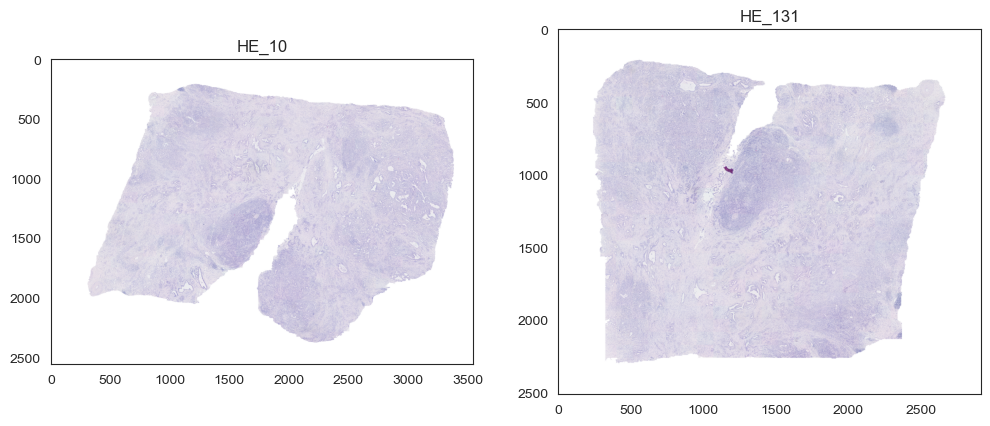

In [14]:



def _mask_outside_contour(gdf: gpd.GeoDataFrame, da_img: da.Array|np.ndarray, fill_value=0):
    gdf["clusters"] = 1
    mask = gdf_shape_to_image(gdf, w=da_img.shape[1], h=da_img.shape[0])
    mask = np.repeat(mask[:, :, None], da_img.shape[2], axis=2)
    if isinstance(da_img, da.Array):
        da_img = da_img.compute()

    da_img[mask==0] = 255
    return da_img


### FUNC1: step1_crop_trident
def step1_crop_trident(file_qptiff, file_geojson, ext_ratio=0.1, read_tiff_kwargs=None, **kwargs):
    if read_tiff_kwargs is None:
        read_tiff_kwargs = {}

    with open(file_geojson, 'r') as f:
        geojson_contour = json.load(f)

    l_contours = geojson_contour["features"]
    if len(l_contours) == 0:
        return None

    gdf_coords = gpd.GeoDataFrame(geometry=[shapely.Polygon(contour['geometry']['coordinates'][0]) for contour in l_contours])

    coords = np.array([list(pt) for polygon in gdf_coords.geometry for pt in polygon.exterior.coords])
    min_x, min_y = coords.min(0)
    max_x, max_y = coords.max(0)
    h_, w_ = max_y - min_y, max_x - min_x
    da_img0 = om.tl.read_ome_tiff(file_qptiff, i_page=0, i_level=0)
    h, w = da_img0.shape[0], da_img0.shape[1]
    ext_h, ext_w = h_ * ext_ratio, w_ * ext_ratio
    x_beg, x_end = max(min_x - ext_w, 0), min(max_x + ext_w, w)
    y_beg, y_end = max(min_y - ext_h, 0), min(max_y + ext_h, h)

    x_beg_scaled, x_end_scaled, y_beg_scaled, y_end_scaled = x_beg / w, x_end / w, y_beg / h, y_end / h
    np_coords = np.array([y_beg_scaled, x_beg_scaled, y_end_scaled, x_end_scaled])

    da_img = om.tl.read_ome_tiff(file_qptiff, **read_tiff_kwargs)
    h_out, w_out = da_img.shape[0], da_img.shape[1]

    scale_h = h_out / h
    scale_w = w_out / w
    gdf_coords_scaled = gdf_coords.copy()
    gdf_coords_scaled.geometry = gdf_coords_scaled.geometry.translate(xoff=-x_beg, yoff=-y_beg)
    gdf_coords_scaled.geometry = gdf_coords_scaled.geometry.scale(xfact=scale_w, yfact=scale_h, origin=(0, 0))

    x_beg, x_end = int(x_beg_scaled * w_out), int(x_end_scaled * w_out)
    y_beg, y_end = int(y_beg_scaled * h_out), int(y_end_scaled * h_out)
    da_img = da_img[y_beg:y_end, x_beg:x_end, ...]
    da_img = _mask_outside_contour(gdf_coords_scaled, da_img)
    param = {"crop_size": np_coords, "da_img": da_img}

    return da_img, param



da_img0, param = step1_crop_trident(**attr0.to_dict())
attr0.update(param)

da_img1, param = step1_crop_trident(**attr1.to_dict())
attr1.update(param)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(da_img0)
axes[0].set_title(sample0)
axes[1].imshow(da_img1)
axes[1].set_title(sample1)

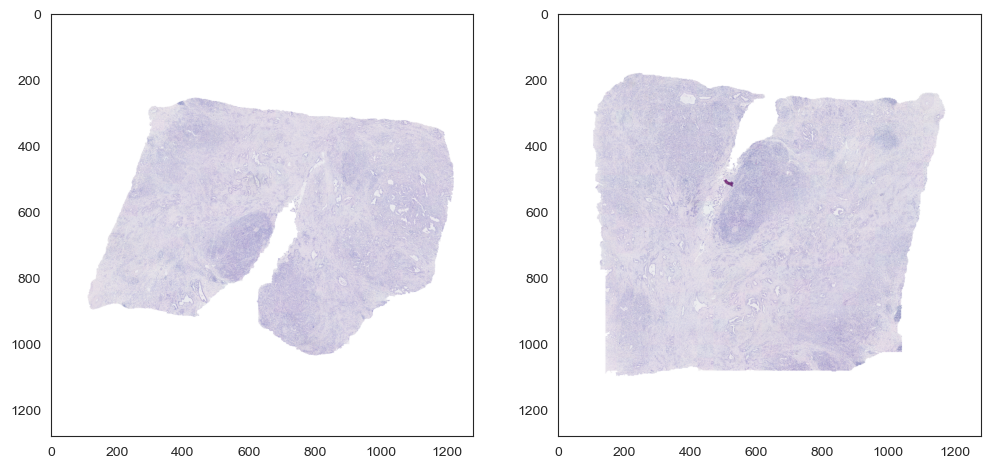

In [15]:
## FUNC2: pad

def step2_pad(da_img, max_size=None, pt_bg=None, **kwargs):
    if max_size is None:
        max_size = [1280, 1280]

    if isinstance(max_size, int):
        max_size = [max_size, max_size]

    padded_tensor, pad_size, ratio = center_pad_with_flank(om.tl.im2tensor(da_img), max_size=max_size, pt_bg=pt_bg)
    param = {"pad_size": pad_size, "ratio": ratio, "tensor": padded_tensor}
    return padded_tensor, param



tensor0, param0 = step2_pad(**attr0)
tensor1, param1 = step2_pad(**attr1)

attr0.update(param0)
attr1.update(param1)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(om.tl.tensor2im(tensor0))
axes[1].imshow(om.tl.tensor2im(tensor1))

Crop offset applied: x=50.33624999999995, y=138.51125
Crop offset applied: x=821.6300000054938, y=3225.8612500054937


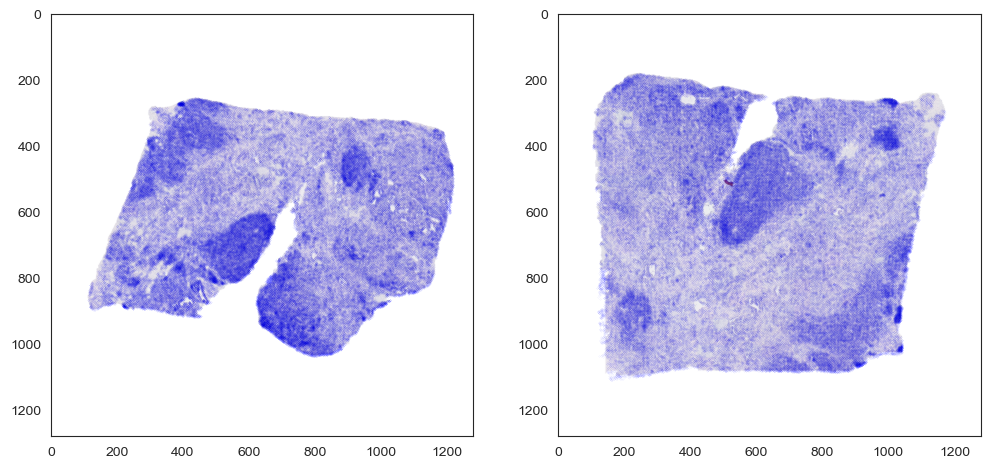

In [16]:
## FUNC3: cells

 
def step3_cell(file_cell_gpd, file_qptiff, crop_size=None, ratio=1.0, pad_size=None, read_tiff_kwargs=None, zoom_level=4, **kwargs):
    """
    Transform cell geometries from original coordinates to padded image coordinates.
    
    Transformation steps:
    1. Load cells with geometries
    2. Scale by pyramid level (2^zoom_level)
    3. Apply crop offset (if cropped)
    4. Scale by resize ratio
    5. Apply padding offset
    """
    if read_tiff_kwargs is None:
        read_tiff_kwargs = {}
    
    da_img = om.tl.read_ome_tiff(file_qptiff, **read_tiff_kwargs)
    gdf = gpd.read_parquet(file_cell_gpd)
    
    # Step 1: Scale by pyramid level
    scale_factor = 1.0 / (2 ** zoom_level)
    gdf_transformed = gdf.copy()
    gdf_transformed.geometry = gdf_transformed.geometry.scale(
        xfact=scale_factor, yfact=scale_factor, origin=(0, 0)
    )
    
    # Step 2: Apply crop offset
    if crop_size is not None:
        y1, x1, y2, x2 = crop_size
        h, w = da_img.shape[0], da_img.shape[1]
        x_offset = x1 * w
        y_offset = y1 * h
        print(f'Crop offset applied: x={x_offset}, y={y_offset}')
        gdf_transformed.geometry = gdf_transformed.geometry.translate(
            xoff=-x_offset, yoff=-y_offset
        )
    
    # Step 3: Scale by resize ratio
    gdf_transformed.geometry = gdf_transformed.geometry.scale(
        xfact=1/ratio, yfact=1/ratio, origin=(0, 0)
    )
    
    # Step 4: Apply padding offset
    if pad_size is not None:
        pad_left, pad_right, pad_top, pad_bottom = pad_size
        gdf_transformed.geometry = gdf_transformed.geometry.translate(
            xoff=pad_left, yoff=pad_top
        )
    
    param = {"gdf_cell": gdf_transformed}
    return gdf_transformed, param


file_qptiff = f'/cluster/home/bqhu_jh/projects/scGaussian3dGen/data/panlab/pdac2/{sample0}.qptiff'
file_cell_gpd = f'/cluster/home/bqhu_jh/projects/scGaussian3dGen/analysis/panlab/v6/lazy_slide/pdac2/{sample0}_cellseg_plip.zarr/shapes/cells/shapes.parquet'
gdf0, param = step3_cell(**attr0.to_dict())
attr0.update(param)
np_kpts0 = np.array([[x, y] for x, y in zip(gdf0.centroid.x, gdf0.centroid.y)])

file_qptiff = f'/cluster/home/bqhu_jh/projects/scGaussian3dGen/data/panlab/pdac2/{sample1}.qptiff'
file_cell_gpd = f'/cluster/home/bqhu_jh/projects/scGaussian3dGen/analysis/panlab/v6/lazy_slide/pdac2/{sample1}_cellseg_plip.zarr/shapes/cells/shapes.parquet'
gdf1, param = step3_cell(**attr1.to_dict())
attr1.update(param)
np_kpts1 = np.array([[x, y] for x, y in zip(gdf1.centroid.x, gdf1.centroid.y)])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(om.tl.tensor2im(attr0.tensor))
axes[0].scatter(np_kpts0[:, 0], np_kpts0[:, 1], s=0.01, c='b', alpha=0.2)
axes[1].imshow(om.tl.tensor2im(attr1.tensor))
axes[1].scatter(np_kpts1[:, 0], np_kpts1[:, 1], s=0.01, c='b', alpha=0.2)

In [17]:
attr0.pad_size

(0, 0, 178, 179)

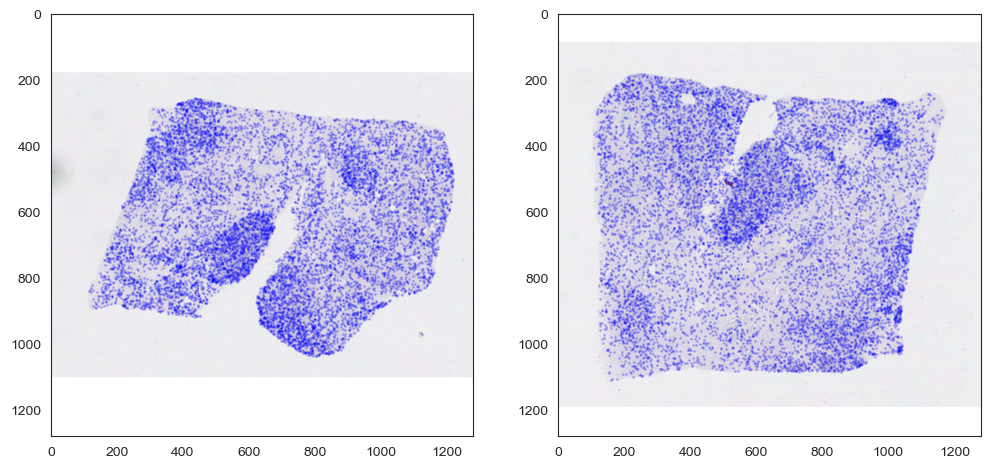

In [18]:
da_img0 = attr0.viz_image(zoom_level=4)
gdf_cell0 = attr0.viz_cells(subsample=10000)
da_img1 = attr1.viz_image(zoom_level=4)
gdf_cell1 = attr1.viz_cells(subsample=10000)
np_kpts0 = np.array([[x, y] for x, y in zip(gdf_cell0.centroid.x, gdf_cell0.centroid.y)])
np_kpts1 = np.array([[x, y] for x, y in zip(gdf_cell1.centroid.x, gdf_cell1.centroid.y)])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(da_img0)
axes[0].scatter(np_kpts0[:, 0], np_kpts0[:, 1], s=1, c='b', alpha=0.2)
axes[1].imshow(da_img1)
axes[1].scatter(np_kpts1[:, 0], np_kpts1[:, 1], s=1, c='b', alpha=0.2)

In [19]:
# FUNC4: find best pose

detector = om.kp.init_detector("roma_dense")

Using coarse resolution (560, 560), and upsample res (1024, 1024)


Angle: 0, Score: -7.338346004486084, FlipX: 1, FlipY: 1
Angle: 45, Score: -6.1436543464660645, FlipX: 1, FlipY: 1
Angle: 90, Score: -5.343551158905029, FlipX: 1, FlipY: 1
Angle: 135, Score: -4.22887659072876, FlipX: 1, FlipY: 1
Angle: 180, Score: -3.3189098834991455, FlipX: 1, FlipY: 1


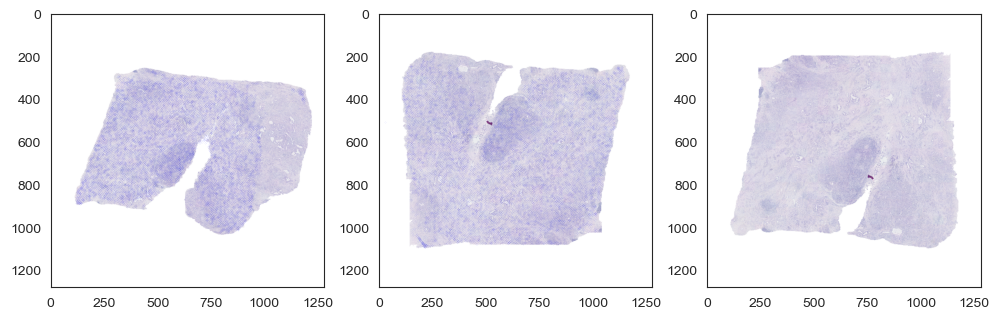

In [20]:


def move_pose(tensor_tfrs_pose, tensor=None, kpt=None, tile_size=512, constant_values=255, max_size=1280, **kwargs):
    tensor_moved, kpt1_raw = None, None
    if tensor is not None:
        da_image_pad = da.from_array(om.tl.tensor2im(tensor), chunks=(tile_size, tile_size, 3))
        da_image_moved = apply_tfrs_to_dask(da_image_pad, [tensor_tfrs_pose], tile_size=(tile_size, tile_size, 1), constant_values=constant_values)
        tensor_moved = om.tl.im2tensor(da_image_moved.compute())

    if kpt is not None:
        grid_M_1_inv = calculate_M_from_theta(tfrs_inv(tensor_tfrs_pose), h=max_size, w=max_size)[0:2]
        kpt1_raw = transform_keypoints(kpt, grid_M_1_inv)

    return tensor_moved, kpt1_raw



def detect_with_pose(tensor0, tensor1, detector, tensor_tfrs_pose=None, tile_size=512, max_size=1280):
    
    if tensor_tfrs_pose is None:
        tensor_tfrs_pose = torch.tensor([np.deg2rad(0), 0, -0, 0, 0, 1.0, 1.0]).float()
    
    tensor1_moved, _ = move_pose(tensor_tfrs_pose, tensor=tensor1)

    kpt0, kpt1, l_idxs, res = om.kp.match(
                tensor0,
                tensor1_moved,
                detector=detector
    )
    kpt0 = kpt0.detach().cpu()
    kpt1 = kpt1.detach().cpu()
    np_masks = F.interpolate(tensor0, size=(128, 128))[0].mean(dim=0).cpu().numpy() < 1.0
    np_certainty = res[8]["certainty"].cpu().detach().numpy()[0, 0]
    np_certainty[np_masks==0] = np.nan
    score = np.nanmean(np_certainty)


    tensor_tfrs_pose_inv = grid_M_to_tfrs(tfrs_inv(tensor_tfrs_pose)[0:2])
    _, kpt1_raw = move_pose(tensor_tfrs_pose_inv, kpt=kpt1)
    # grid_M_1_inv = calculate_M_from_theta(tfrs_inv(tensor_tfrs_pose_inv), h=max_size, w=max_size)[0:2]
    # kpt1_raw = transform_keypoints(kpt1, grid_M_1_inv)


    return kpt0, kpt1_raw, tensor1_moved, l_idxs, res, score
    # grid1 = F.interpolate(res[8]["flow"].detach().cpu(), size=(tensor1.shape[2], tensor1.shape[3]), mode='bilinear', align_corners=False).permute(0,2,3,1)
    # tensor1_to_0 = F.grid_sample(tensor1, grid1[0:1], padding_mode='border')


def detect_best_pose(tensor0, tensor1, detector, l_angles=None, max_size=1280):
    if l_angles is None:
        l_angles = [0, 45, 90, 135, 180, 225, 270, 315]

    best_score = -np.inf
    best_res = None
    
    for flip_x in [1, -1]:
        for flip_y in [1, -1]:
            if flip_x == -1 and flip_y ==-1:
                continue

            for angle in l_angles:
                tensor_tfrs_pose = torch.tensor([np.deg2rad(angle), 0, -0, 0, 0, flip_x, flip_y]).float()
                kpt0, kpt1, tensor1_moved, l_idxs, res, score = detect_with_pose(tensor0, tensor1, detector, tensor_tfrs_pose, max_size=max_size)
                if score > best_score:
                    print(f"Angle: {angle}, Score: {score}, FlipX: {flip_x}, FlipY: {flip_y}")
                    best_score = score
                    best_res = (kpt0, kpt1, l_idxs, res, tensor_tfrs_pose, score)

    return best_res

kpt0, kpt1, l_idxs, res, best_pose, score = detect_best_pose(attr0.tensor, attr1.tensor, detector)

grid_pose = F.affine_grid(tfrs_to_grid_M(best_pose).unsqueeze(0), size=[1, 2, 1280, 1280])
grid_nonrigid = F.interpolate(res[8]["flow"].detach().cpu(), size=(attr1.tensor.shape[2], attr1.tensor.shape[3]), mode='bilinear', align_corners=False).permute(0,2,3,1)[0:1]
attr1.update({
    "tensor_tfrs_pose": best_pose,
    "grid_M" : [grid_pose, grid_nonrigid]
})

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(om.tl.tensor2im(attr0.tensor))
axes[0].scatter(kpt0[:, 0], kpt0[:, 1], s=0.01, c='b', alpha=0.2)
axes[0].set_xlim(0, 1280)
axes[0].set_ylim(0, 1280)
axes[0].invert_yaxis()

axes[1].imshow(om.tl.tensor2im(attr1.tensor))
axes[1].scatter(kpt1[:, 0], kpt1[:, 1], s=0.01, c='b', alpha=0.2)
axes[1].set_xlim(0, 1280)
axes[1].set_ylim(0, 1280)
axes[1].invert_yaxis()

tensor1_to_0, _ = move_pose(**attr1.to_dict())
axes[2].imshow(om.tl.tensor2im(tensor1_to_0))
#axes[1].scatter(kpt1[:, 0], kpt1[:, 1], s=0.01, c='b', alpha=0.2)
axes[2].set_xlim(0, 1280)
axes[2].set_ylim(0, 1280)
axes[2].invert_yaxis()

Transforming back geometries: 100%|██████████| 10000/10000 [00:02<00:00, 3980.47it/s]


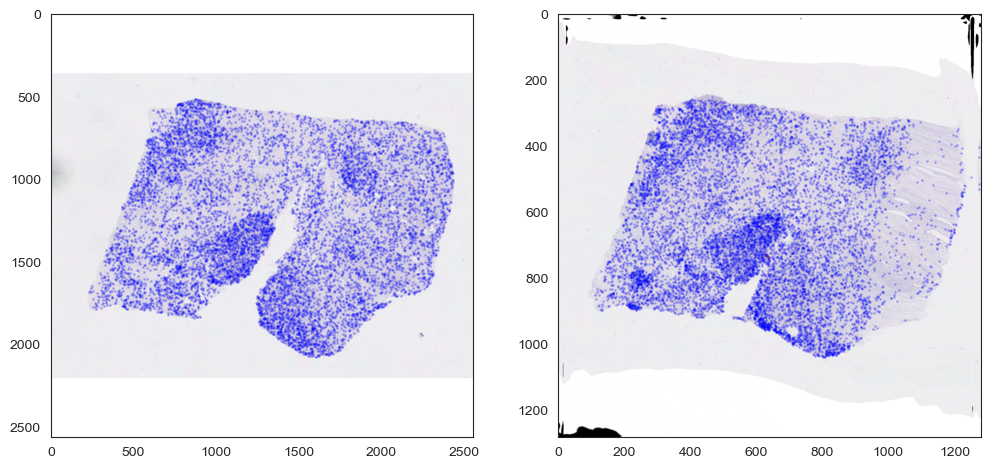

In [24]:
da_img0 = attr0.viz_image(zoom_level=3)
gdf_cell0 = attr0.viz_cells(subsample=10000)

da_img1 = attr1.viz_image(zoom_level=4)
gdf_cell1 = attr1.viz_cells(subsample=10000)
np_kpts0 = np.array([[x, y] for x, y in zip(gdf_cell0.centroid.x, gdf_cell0.centroid.y)])
np_kpts1 = np.array([[x, y] for x, y in zip(gdf_cell1.centroid.x, gdf_cell1.centroid.y)])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(da_img0)
axes[0].scatter(np_kpts0[:, 0]* 2, np_kpts0[:, 1]*2, s=1, c='b', alpha=0.2)
axes[1].imshow(da_img1)
axes[1].scatter(np_kpts1[:, 0], np_kpts1[:, 1], s=1, c='b', alpha=0.2)

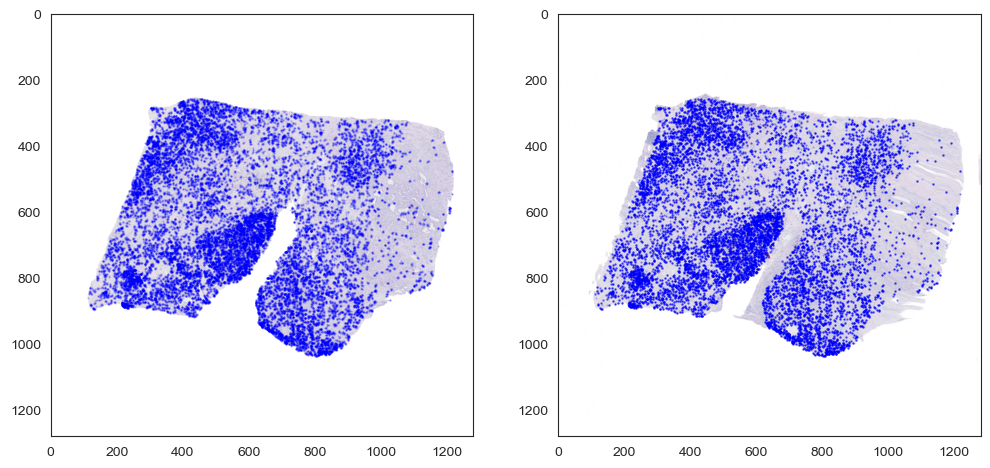

In [ ]:
from omnialigner.utils.mnn_fast import calculate_overlapped_mnn_pairs, calculate_distance_for_pairs


mnn_pair = calculate_overlapped_mnn_pairs(torch.from_numpy(np_kpts0).float(), torch.from_numpy(np_kpts1).float())
dist_spatial, dist_corr, mnn_dists = calculate_distance_for_pairs(
    mnn_pair, torch.from_numpy(np_kpts0).float(), torch.from_numpy(np_kpts1).float()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(om.tl.tensor2im(attr0.tensor))
axes[0].scatter(np_kpts0[mnn_pair[:,0], 0], np_kpts0[mnn_pair[:,0], 1], s=0.4, c='b', alpha=0.2)
axes[0].set_xlim(0, 1280)
axes[0].set_ylim(0, 1280)
axes[0].invert_yaxis()

axes[1].imshow(da_img1)
axes[1].scatter(np_kpts1[mnn_pair[:,1], 0], np_kpts1[mnn_pair[:,1], 1], s=0.4, c='b', alpha=0.2)
axes[1].set_xlim(0, 1280)
axes[1].set_ylim(0, 1280)
axes[1].invert_yaxis()

# Cells

Calculating overlaps: 100%|██████████| 170976/170976 [02:46<00:00, 1029.60it/s]


Total cells in gdf0: 170976
Total cells in gdf1_transformed: 182019
Matched pairs (IoU >= 0.2): 6336
Match rate: 3.71%

Top 10 matches by overlap:
  gdf0[103744] <-> gdf1[112411]: IoU = 0.551
  gdf0[161059] <-> gdf1[154274]: IoU = 0.535
  gdf0[31942] <-> gdf1[28441]: IoU = 0.491
  gdf0[165303] <-> gdf1[174669]: IoU = 0.481
  gdf0[154343] <-> gdf1[154341]: IoU = 0.475
  gdf0[77496] <-> gdf1[65322]: IoU = 0.472
  gdf0[46105] <-> gdf1[50655]: IoU = 0.469
  gdf0[8637] <-> gdf1[4501]: IoU = 0.467
  gdf0[158125] <-> gdf1[151329]: IoU = 0.456
  gdf0[170506] <-> gdf1[175903]: IoU = 0.453


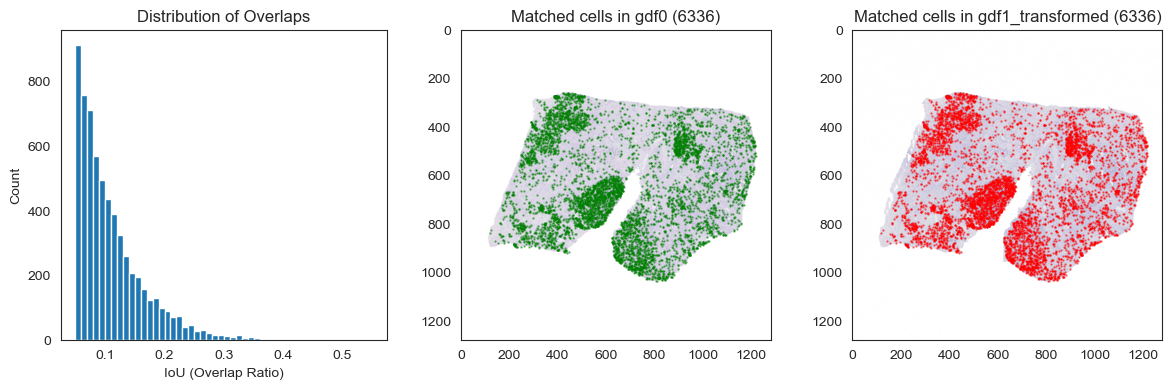

In [108]:
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from shapely.validation import make_valid

def calculate_overlap_matches(gdf0, gdf1_transformed, overlap_threshold=0.2):
    """
    Calculate overlap between geometries in two GeoDataFrames.
    
    Returns:
        matched_pairs: list of tuples (idx0, idx1, overlap_ratio)
        overlap_matrix: numpy array of shape (len(gdf0), len(gdf1_transformed))
    """
    n0 = len(gdf0)
    n1 = len(gdf1_transformed)
    
    # Initialize overlap matrix
    overlap_matrix = np.zeros((n0, n1))
    matched_pairs = []
    
    # Build spatial index using centroids for quick filtering
    centroids0 = np.array([[g.centroid.x, g.centroid.y] for g in gdf0.geometry])
    centroids1 = np.array([[g.centroid.x, g.centroid.y] for g in gdf1_transformed.geometry])
    
    # Use KDTree for efficient nearest neighbor search
    tree1 = cKDTree(centroids1)
    
    for idx0 in tqdm(range(n0), desc="Calculating overlaps"):
        geom0 = gdf0.loc[idx0, 'geometry']
        
        # Fix invalid geometry
        if not geom0.is_valid:
            geom0 = make_valid(geom0)
        
        # Find nearby candidates (within reasonable distance)
        dist, candidates = tree1.query(centroids0[idx0], k=min(10, n1))
        
        # Handle single candidate case
        if not isinstance(candidates, np.ndarray):
            candidates = [candidates]
        
        for idx1 in candidates:
            geom1 = gdf1_transformed.loc[idx1, 'geometry']
            
            # Fix invalid geometry
            if not geom1.is_valid:
                geom1 = make_valid(geom1)
            
            try:
                # Calculate overlap
                if geom0.intersects(geom1):
                    intersection_area = geom0.intersection(geom1).area
                    union_area = geom0.area + geom1.area - intersection_area  # More stable calculation
                    
                    if union_area > 0:
                        overlap_ratio = intersection_area / union_area  # IoU
                        overlap_matrix[idx0, idx1] = overlap_ratio
                        
                        if overlap_ratio >= overlap_threshold:
                            matched_pairs.append((idx0, idx1, overlap_ratio))
            except Exception as e:
                # Skip problematic geometries
                print(f"Warning: Failed to calculate overlap for pair ({idx0}, {idx1}): {e}")
                continue
    
    return matched_pairs, overlap_matrix

# Calculate overlaps
matched_pairs, overlap_matrix = calculate_overlap_matches(gdf0, gdf1_transformed, overlap_threshold=0.05)

# Print statistics
print(f"Total cells in gdf0: {len(gdf0)}")
print(f"Total cells in gdf1_transformed: {len(gdf1_transformed)}")
print(f"Matched pairs (IoU >= 0.2): {len(matched_pairs)}")
print(f"Match rate: {len(matched_pairs) / len(gdf0) * 100:.2f}%")

# Show top matches
print("\nTop 10 matches by overlap:")
sorted_matches = sorted(matched_pairs, key=lambda x: x[2], reverse=True)[:10]
for idx0, idx1, overlap in sorted_matches:
    print(f"  gdf0[{idx0}] <-> gdf1[{idx1}]: IoU = {overlap:.3f}")

# Visualize overlap distribution
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.hist([m[2] for m in matched_pairs], bins=50)
plt.xlabel('IoU (Overlap Ratio)')
plt.ylabel('Count')
plt.title('Distribution of Overlaps')

plt.subplot(132)
plt.imshow(om.tl.tensor2im(tensor0))
matched_idx0 = [m[0] for m in matched_pairs]
matched_centroids0 = np.array([[gdf0.loc[i, 'geometry'].centroid.x, 
                                 gdf0.loc[i, 'geometry'].centroid.y] for i in matched_idx0])
plt.scatter(matched_centroids0[:, 0], matched_centroids0[:, 1], s=0.5, c='g', alpha=0.5)
plt.title(f'Matched cells in gdf0 ({len(matched_pairs)})')

plt.subplot(133)
plt.imshow(om.tl.tensor2im(tensor1_to_0))
matched_idx1 = [m[1] for m in matched_pairs]
matched_centroids1 = np.array([[gdf1_transformed.loc[i, 'geometry'].centroid.x,
                                 gdf1_transformed.loc[i, 'geometry'].centroid.y] for i in matched_idx1])
plt.scatter(matched_centroids1[:, 0], matched_centroids1[:, 1], s=0.5, c='r', alpha=0.5)
plt.title(f'Matched cells in gdf1_transformed ({len(matched_pairs)})')

plt.tight_layout()